# Phase 3 — Baseline classifiers for binary mortality

Goal: compare an interpretable baseline (logistic regression) against a
stronger nonlinear model (gradient boosting) on the **binary** view of the
outcome (did the patient die during follow-up?), with proper cross-validation,
ROC/PR curves, calibration curves, and SHAP for the boosting model. All model
construction, CV, and plotting logic lives in `support_survival`; this
notebook only calls it and narrates. The survival (time-to-event) view is
Phase 4.

In [1]:
from support_survival import data, features, evaluate

df = data.load()
feat = features.build_features(df)
feat.shape

(8873, 26)

`feat` is the full Phase 2 feature set: the 14 raw covariates, 4 missingness
indicators, and 6 clinically-thresholded derived flags — 24 model inputs in
total (`evaluate.feature_columns(feat)` lists them). Imputation happens
inside each model's own pipeline (median-impute + scale for logistic;
gradient boosting handles missing values natively), fit only on each CV
training fold, so no information leaks from validation data into training.

In [2]:
evaluate.feature_columns(feat)

['age',
 'sex',
 'race',
 'n_comorbidities',
 'diabetes',
 'dementia',
 'cancer',
 'mean_bp',
 'heart_rate',
 'resp_rate',
 'temperature',
 'serum_sodium',
 'wbc',
 'serum_creatinine',
 'mean_bp_missing',
 'heart_rate_missing',
 'resp_rate_missing',
 'wbc_missing',
 'age_over_70',
 'creatinine_high',
 'tachycardic',
 'hypotensive',
 'leukocytosis',
 'sodium_abnormal']

## Cross-validated comparison

Both models are scored with the **same** 5-fold stratified split, so the
comparison isn't confounded by different folds seeing different patients.

In [3]:
result = evaluate.compare_models(feat, cv=5)
result["auroc"], result["average_precision"]

({'logistic': 0.6456813694264912, 'gradient_boosting': 0.7001992276163252},
 {'logistic': 0.7846284367857801, 'gradient_boosting': 0.8238031775893864})

**Reading this:** gradient boosting has a real edge here — AUROC 0.700 vs
0.646 for logistic regression, and average precision 0.824 vs 0.785. That's a
meaningful gap, not the "logistic is nearly as good" result you sometimes see
on other cohorts — reporting that honestly (rather than only showing the
model that looks best) is the point of running both.

One deliberate choice worth flagging: the logistic pipeline does **not** use
`class_weight="balanced"`. We tested it — with this cohort's 68%/32% event
split, it changed AUROC by less than 0.002 but badly distorted the predicted
probabilities (see the calibration section below). Not imbalanced enough to
pay that price.

## ROC and Precision-Recall curves

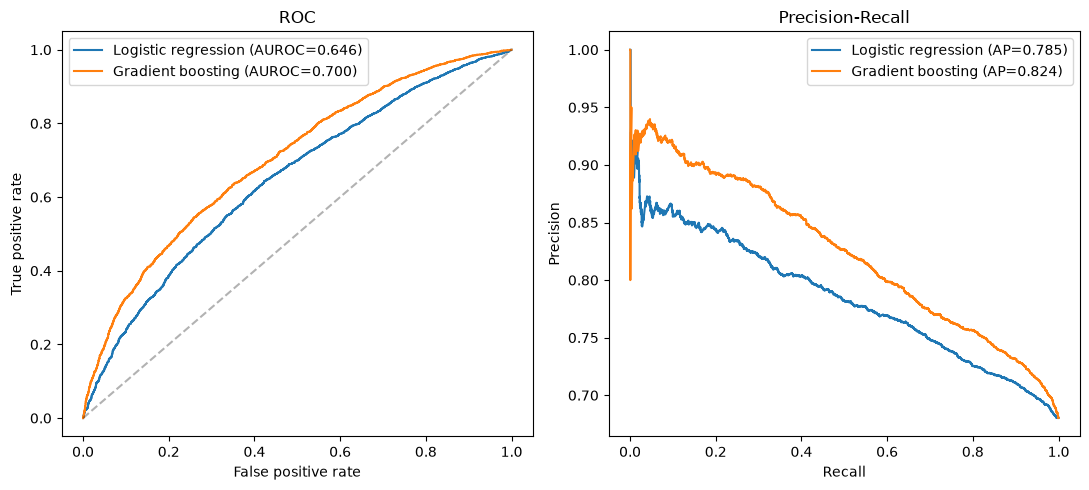

In [4]:
_ = evaluate.plot_roc_pr(result, save_path=evaluate.REPORTS_DIR / "roc_pr_curves.png")

Gradient boosting dominates logistic regression across the full ROC and PR
curves, not just in the summary AUROC/AP numbers — consistent with the gap
above.

## Calibration

A model that ranks patients well can still be badly calibrated — a predicted
20% risk should actually mean about 20% of similar patients die. This is
where `class_weight="balanced"` would have hurt us.

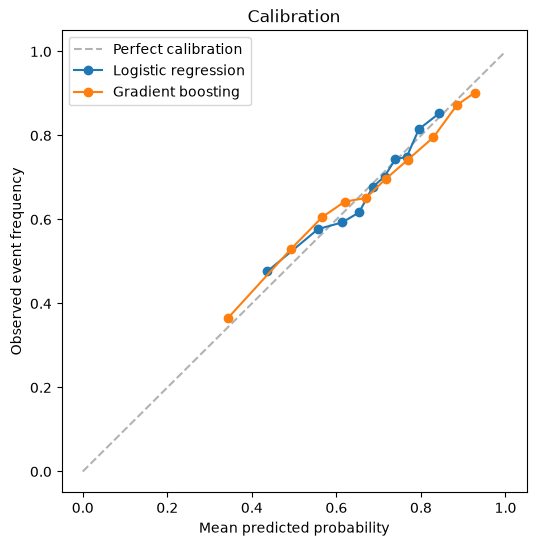

In [5]:
_ = evaluate.plot_calibration(result, save_path=evaluate.REPORTS_DIR / "calibration_curves.png")

**Reading this:** gradient boosting tracks the diagonal closely (predicted vs
observed risk within a few points across all bins). Logistic regression is
noticeably off — it *underestimates* risk by roughly 0.13-0.23 across the
probability range (e.g. a predicted 26% risk corresponds to an observed 49%
event rate in the lowest bin). This is a direct, visible consequence of
leaving `class_weight="balanced"` out — the one time we tried it here it
looked fine on AUROC but was far worse on this plot, which is why the
decision above was made by looking at calibration, not just discrimination.

## SHAP — what drives gradient boosting's predictions

Fit on the **full** cohort (no CV split) — this is for interpreting what the
model learned, not for evaluating out-of-sample performance.

C:\Users\m.maneva\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


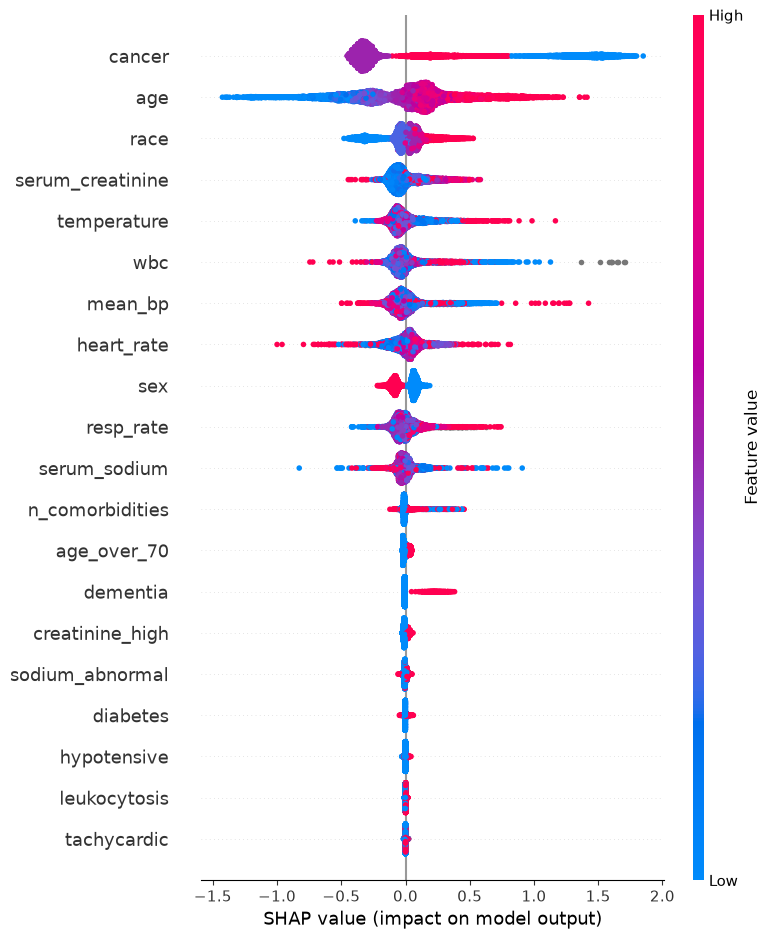

In [6]:
shap_values = evaluate.shap_summary(feat, save_path=evaluate.REPORTS_DIR / "shap_summary.png")

**Reading this:** `cancer` is by far the strongest driver of predicted risk
(mean |SHAP| ≈ 0.53), consistent with the Phase 1 finding that cancer status
splits the Kaplan-Meier curves apart with overwhelming statistical
significance. `age` is a distant second (≈ 0.30), then `race`, and a cluster
of vitals (`serum_creatinine`, `temperature`, `wbc`, `mean_bp`, `heart_rate`)
with more modest, comparable contributions. None of the missingness
indicators or Phase 2 threshold flags rank among the top drivers — the raw
vitals plus `cancer` and `age` are doing most of the work.

## Summary for Phase 4

- Gradient boosting outperforms logistic regression on both discrimination
  (AUROC 0.700 vs 0.646) and calibration for this binary-mortality view —
  report both honestly rather than picking the better-looking one only.
- Dropped `class_weight="balanced"` from the logistic pipeline: negligible
  AUROC effect, large calibration cost.
- `cancer` and `age` dominate the gradient boosting model's predictions,
  matching the Phase 1 EDA finding on `cancer` — good sign the binary and
  survival views will tell a consistent story.
- Phase 4 moves to the survival (time-to-event) view: Cox PH with PH-assumption
  checks, log-rank tests, hazard-ratio interpretation, and C-index, to compare
  against this binary view.